ordenar bloques por colores - aprendizaje por refuerzo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
np.random.seed(42)
mu, sigma = 0, 1
q = {k+1: v for k, v in enumerate(np.random.normal(mu, sigma, 4))}
q

{1: np.float64(0.4967141530112327),
 2: np.float64(-0.13826430117118466),
 3: np.float64(0.6476885381006925),
 4: np.float64(1.5230298564080254)}

In [3]:
partidas = 1000
turnos = 100
epsilons = [0, 0.01, 0.1]
recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))

for ej in range(partidas):
    mejor_accion = max(q, key=q.get)
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(1, 5)}
        acciones = {k: 0 for k in range(1, 5)}
        recompensas = {k: 0 for k in range(1, 5)}
        for exp in range(turnos):
            if np.random.uniform(0, 1) < e:
                a = np.random.randint(4) + 1
            else:
                maxQ = -100
                for j in range(1, 5):
                    if Q[j] > maxQ:
                        maxQ = Q[j]
                        a = j
            acciones[a] += 1
            recompensa = q[a]
            recompensas[a] += recompensa
            Q[a] = recompensas[a] / acciones[a]
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

recompensas_medias /= partidas
acciones_optimas /= partidas

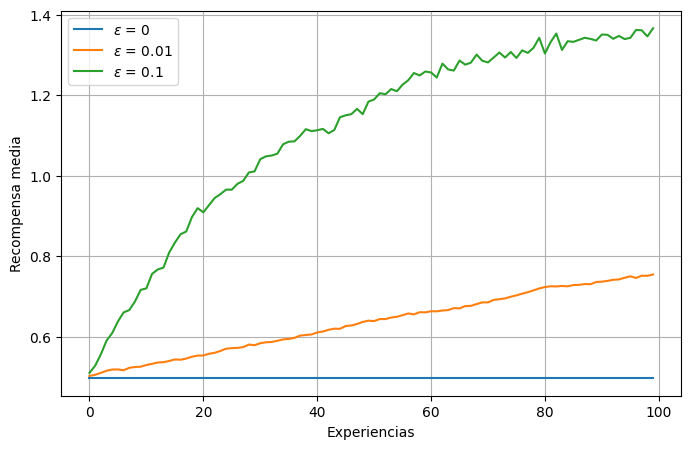

In [4]:
plt.figure(figsize=(8, 5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'$\\epsilon$ = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.show()

In [5]:
partidas = 1000
turnos = 100
alpha = 0.5
c = 1
epsilons = [0.1, 0.1]
recompensas_medias = np.zeros((len(epsilons), turnos))
acciones_optimas = np.zeros((len(epsilons), turnos))

for ej in range(partidas):
    mejor_accion = max(q, key=q.get)
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(1, 5)}
        acciones = {k: 1 for k in range(1, 5)}
        for exp in range(turnos):
            if i == 0: # ucb
                maxQ = -100
                for j in range(1, 5):
                    A = Q[j] + c * math.sqrt(math.log(exp + 1) / acciones[j])
                    if A > maxQ:
                        maxQ = A
                        a = j
            else:
                if np.random.uniform(0, 1) < e:
                    a = np.random.randint(4) + 1
                else:
                    maxQ = -100
                    for j in range(1, 5):
                        if Q[j] > maxQ:
                            maxQ = Q[j]
                            a = j
            acciones[a] += 1
            recompensa = q[a]
            Q[a] += alpha * (recompensa - Q[a])
            recompensas_medias[i][exp] += recompensa
            acciones_optimas[i][exp] += (a == mejor_accion)

recompensas_medias /= partidas
acciones_optimas /= partidas

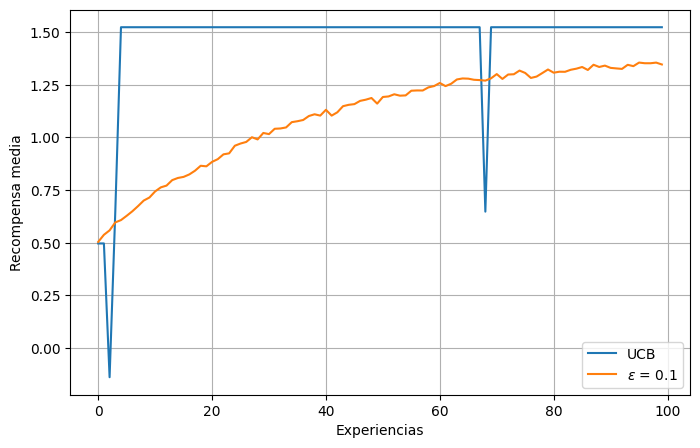

In [6]:
plt.figure(figsize=(8, 5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'$\\epsilon$ = {e}' if i != 0 else 'UCB')
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.show()